*Francisco Pereira [camara@dtu.dk], DTU Management*



# Advanced Business Analytics

## Lecture 1 - Web Data Mining - Part 3: Environmental data streams

In this notebook, we explore existing APIs for environmental data. The ones used here are just examples. We strongly recommend interested students to search by themselves for the alternatives that best suit them.

***note: We will use primarily the opensensorweb API. Its access was kindly provided by the host company (PIKOBYTES.de). They only require us to consistently use thisAPI key.***

In [1]:
key="tk1.06sue462ck4q9mqeg8na"

***Please make sure that you always use it as shown in the examples below.***

### 1. A few initial requests


#### 1.1.   Studying an API documentation

Open the file "api-documentation-for-readers.md" with some text editor. Take a quick look.



The first thing to do, is understand what the "base URL" should be. In our case, it will always be "https://api.opensensorweb.de/"

The second thing we can notice, is that the structure of a call always has 

/{api-version}/networks{/network}/devices{/device}/sensors{/sensor}/measurements followed by "?token={apikey}"

Now, it is up to you to decide to what depth of this sequence you want to go to... For example, to get the list of of the devices available in the EEA-air network, you'd do 

https://api.opensensorweb.de/v0/networks/EEA-air/devices?token=tk1.06sue462ck4q9mqeg8na&

You can even click on this link to make the call itself on the browser...

#### 1.2. Experimenting with different requests

Let’s do some imports

In [2]:
import requests
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from datetime import datetime


/var/folders/vk/wc7mk0p13r31xnm_nqv76gnh0000gp/T/ipykernel_52232/3820524854.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


_Get the list of existing networks_

In [3]:
baseurl="https://api.opensensorweb.de/v0/"

In [4]:
url=baseurl+"networks?token="+key
response=requests.get(url)
networks=response.json()

In [5]:
networks

{'request': 'https://api.opensensorweb.de/v0/networks?token=tk1.06sue462ck4q9mqeg8na',
 'total': 50,
 'items': [{'name': 'AIRLY',
   'href': 'https://api.opensensorweb.de/v0/networks/AIRLY'},
  {'name': 'AMMS_WETTERDATEN',
   'href': 'https://api.opensensorweb.de/v0/networks/AMMS_WETTERDATEN'},
  {'name': 'BAFG', 'href': 'https://api.opensensorweb.de/v0/networks/BAFG'},
  {'name': 'bast-traffic',
   'href': 'https://api.opensensorweb.de/v0/networks/bast-traffic'},
  {'name': 'BFS', 'href': 'https://api.opensensorweb.de/v0/networks/BFS'},
  {'name': 'BFSODL',
   'href': 'https://api.opensensorweb.de/v0/networks/BFSODL'},
  {'name': 'DWD', 'href': 'https://api.opensensorweb.de/v0/networks/DWD'},
  {'name': 'EEA-air',
   'href': 'https://api.opensensorweb.de/v0/networks/EEA-air'},
  {'name': 'EPA-AIR',
   'href': 'https://api.opensensorweb.de/v0/networks/EPA-AIR'},
  {'name': 'FBB_Fluglaerm',
   'href': 'https://api.opensensorweb.de/v0/networks/FBB_Fluglaerm'},
  {'name': 'GHCN', 'href': 

_Get the list of devices belonging to a network of your choice_

In [6]:
my_network="EEA-air"
url=baseurl+"networks/"+my_network+"/devices?token="+key
response=requests.get(url)
devices=response.json()

In [7]:
devices['items'][:10]

[{'name': 'BG0081A',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/BG0081A'},
 {'name': 'GIB_Station_GB0050A',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/GIB_Station_GB0050A'},
 {'name': 'GIB_Station_GB0051A',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/GIB_Station_GB0051A'},
 {'name': 'GIB_Station_GB0951A',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/GIB_Station_GB0951A'},
 {'name': 'HR_DOC_TYPE_D_STA_IS0201',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/HR_DOC_TYPE_D_STA_IS0201'},
 {'name': 'HR_DOC_TYPE_D_STA_RH0101',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/HR_DOC_TYPE_D_STA_RH0101'},
 {'name': 'HR_DOC_TYPE_D_STA_RH0103',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/HR_DOC_TYPE_D_STA_RH0103'},
 {'name': 'HR_DOC_TYPE_D_STA_RH0104',
  'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/HR_DOC_TYPE_D_STA_RH

_Get the list of sensors from a device of your choice_

In [8]:
my_device="BG0081A"
url=baseurl+"networks/"+my_network+"/devices/"+my_device+"/sensors?token="+key
response=requests.get(url)
sensors=response.json()

In [9]:
sensors

{'request': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/BG0081A/sensors?token=tk1.06sue462ck4q9mqeg8na',
 'total': 2,
 'items': [{'name': 'SPO-BG0081A_00001_100-SO2-PT1H',
   'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/BG0081A/sensors/SPO-BG0081A_00001_100-SO2-PT1H'},
  {'name': 'SPO-BG0081A_00005_100-PM10-PT1H',
   'href': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/BG0081A/sensors/SPO-BG0081A_00005_100-PM10-PT1H'}]}

Get the list of measurements from a sensor of your choice (check the documentation to learn how to specify an interval)

In [10]:
my_sensor=sensors['items'][0]['name']
url=baseurl+"networks/"+my_network+"/devices/"+my_device+"/sensors/"+my_sensor+"/measurements?token="+key+"&interval=R744/2018-01-01T00:00:00Z/PT1H"
response=requests.get(url)
measurements=response.json()

In [11]:
measurements

[{'begin': '2018-01-01T00:00Z', 'v': 4.42, 'hi': 4.8, 'lo': 4.04, 'c': 0.0},
 {'begin': '2018-01-01T01:00Z', 'v': 5.19, 'hi': 5.59, 'lo': 4.8, 'c': 0.0},
 {'begin': '2018-01-01T02:00Z', 'v': 5.09, 'hi': 5.59, 'lo': 4.59, 'c': 0.0},
 {'begin': '2018-01-01T03:00Z', 'v': 4.59, 'hi': 4.59, 'lo': 4.58, 'c': 0.0},
 {'begin': '2018-01-01T04:00Z', 'v': 4.37, 'hi': 4.58, 'lo': 4.15, 'c': 0.0},
 {'begin': '2018-01-01T05:00Z', 'v': 3.98, 'hi': 4.15, 'lo': 3.81, 'c': 0.0},
 {'begin': '2018-01-01T06:00Z', 'v': 3.55, 'hi': 3.81, 'lo': 3.29, 'c': 0.0},
 {'begin': '2018-01-01T07:00Z', 'v': 3.53, 'hi': 3.78, 'lo': 3.29, 'c': 0.0},
 {'begin': '2018-01-01T08:00Z', 'v': 3.79, 'hi': 3.8, 'lo': 3.78, 'c': 0.0},
 {'begin': '2018-01-01T09:00Z', 'v': 3.82, 'hi': 3.85, 'lo': 3.8, 'c': 0.0},
 {'begin': '2018-01-01T10:00Z', 'v': 3.75, 'hi': 3.85, 'lo': 3.64, 'c': 0.0},
 {'begin': '2018-01-01T11:00Z', 'v': 3.74, 'hi': 3.85, 'lo': 3.64, 'c': 0.0},
 {'begin': '2018-01-01T12:00Z', 'v': 3.85, 'hi': 3.85, 'lo': 3.85, '

#### 1.3. Getting and visualizing device locations

This kind of data is associated to a geographical location. This API allows you to get the location of any device. 

_Get the location of the device you chose above_

In [12]:

def retrieve_location(key, network, device, api_version="v0"):
    url="https://api.opensensorweb.de/"+api_version+"/networks/"+network+"/devices/"+device
    res = requests.get(url+"?token="+key+"&")
    jsonres=json.loads(res.content)
    return jsonres



In [13]:
location=retrieve_location(key, my_network, my_device)

In [14]:
location

{'code': 'BG0081A',
 'name': 'BG0081A',
 'description': None,
 'registered': None,
 'timezone': 'Europe/Sofia',
 'geometry': {'type': 'Point', 'coordinates': [22.867589, 43.998932]},
 'additional_properties': None,
 'sensors_url': 'https://api.opensensorweb.de/v0/networks/EEA-air/devices/BG0081A/sensors'}

_Visualize all the locations associated to the network you chose_

In [15]:
my_devices=[h['name'] for h in devices['items']]
my_places={}
length=len(my_devices)
count=0
for dev in my_devices:
    print(count, "/", length, ":", dev)
    my_places[dev]=retrieve_location(key, my_network, dev)['geometry']['coordinates']
    count+=1

0 / 1000 : BG0081A
1 / 1000 : GIB_Station_GB0050A
2 / 1000 : GIB_Station_GB0051A
3 / 1000 : GIB_Station_GB0951A
4 / 1000 : HR_DOC_TYPE_D_STA_IS0201
5 / 1000 : HR_DOC_TYPE_D_STA_RH0101
6 / 1000 : HR_DOC_TYPE_D_STA_RH0103
7 / 1000 : HR_DOC_TYPE_D_STA_RH0104
8 / 1000 : HR_DOC_TYPE_D_STA_RH0105
9 / 1000 : HR_DOC_TYPE_D_STA_RH0106
10 / 1000 : HR_DOC_TYPE_D_STA_RH0108
11 / 1000 : HR_DOC_TYPE_D_STA_RH0109
12 / 1000 : HR_DOC_TYPE_D_STA_RH0111
13 / 1000 : HR_DOC_TYPE_D_STA_RH0112
14 / 1000 : HR_DOC_TYPE_D_STA_RH0113
15 / 1000 : HR_DOC_TYPE_D_STA_RH0114
16 / 1000 : HR_DOC_TYPE_D_STA_RH0115
17 / 1000 : HR_DOC_TYPE_D_STA_RH0117
18 / 1000 : HR_DOC_TYPE_D_STA_RH0118
19 / 1000 : HR_DOC_TYPE_D_STA_RH0120
20 / 1000 : HR_DOC_TYPE_D_STA_RH0122
21 / 1000 : HR_DOC_TYPE_D_STA_RH0123
22 / 1000 : HR_DOC_TYPE_D_STA_RH0124
23 / 1000 : HR_DOC_TYPE_D_STA_RH0126
24 / 1000 : HR_DOC_TYPE_D_STA_RH0127
25 / 1000 : HR_DOC_TYPE_D_STA_RH0128
26 / 1000 : HR_DOC_TYPE_D_STA_RH0129
27 / 1000 : HR_DOC_TYPE_D_STA_RH0130
28 / 1

In [16]:
f=open("my_locations.csv", "w")
lats=[]
longs=[]
for latlong in my_places.values():
    la, lo=latlong[1], latlong[0]
    lats.append(la)
    longs.append(lo)
    f.write(str(la)+ ", "+str(lo)+"\n")
f.close()

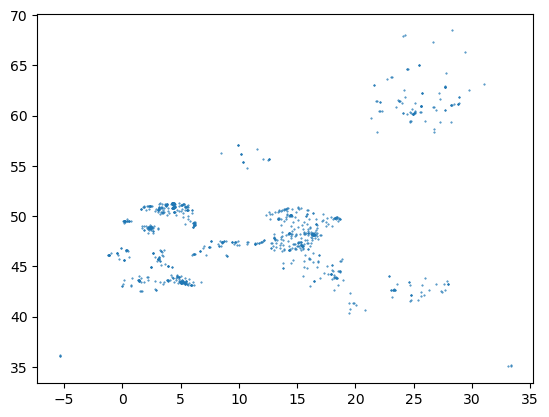

In [17]:
plt.scatter(longs, lats, s=0.2)

Can you show this on a map?

#### 1.4. Loading measurement data

It is time now to start collecting actual data. First, let us get some general statistics of the platform... just call

https://api.opensensorweb.de/v0/summary?token=tk1.06sue462ck4q9mqeg8na


In [18]:
url="https://api.opensensorweb.de/v0/summary?token=tk1.06sue462ck4q9mqeg8na"
requests.get(url).json()

{'networks': 50,
 'devices': 337633,
 'sensors': 902001,
 'measurements': 107993230620}

A lot of data, right? We need to be selective! You'll notice that there are different types of environmental phenomena being measured. What we want is to make a histogram of the amount of measurements that exist for each phenomenon across our chosen network.

Because this may be a bit confusing, we wrote some cofe for you. Check below

In [19]:
def retrieve(key, endpoint, api_structure, api_version="v0"):
    call=""
    
    for c in ['networks', 'devices', 'sensors']:
        res_dic=api_structure.get(c, "")
        if res_dic=="":
            break
        else:
            call+="/"+c+"/"+res_dic

    url="https://api.opensensorweb.de/"+api_version+call+"/"+endpoint+"?token="+key+"&"
    #url="https://api.opensensorweb.de/v0/networks/EEA-air?token="+key+"&"
    res = requests.get(url)
    print(url)
    #print(res)
    jsonres=json.loads(res.content)
    return jsonres


def retrieve_sensor(key, network, device, sensor, api_version="v0"):
    url="https://api.opensensorweb.de/"+api_version+"/networks/"+network+"/devices/"+device+"/sensors/"+sensor
    res = requests.get(url+"?token="+key+"&")
    #print(url)
    #print(res)
    jsonres=json.loads(res.content)
    return jsonres




### This code will take some time to run!

In [20]:
codes={}
count=0
length=len(my_places.keys())
for my_dev in my_places.keys():
    ll=retrieve(key, "sensors", {'networks':my_network, 'devices':my_dev})
    print(count, "/ ",length,", ", my_dev, ":")
    count+=1
    for item in ll['items']:
        print("\t"+item['name'])
        ss=retrieve_sensor(key, my_network, my_dev, item['name'])
        code=ss['phenomenon']['code']
        days_with_data=ss['sensor_stats']['days_with_data']
        if days_with_data=='null':
            days_with_data=0
        codes[code]=codes.get(code, [])
        codes[code].append((my_dev, int(days_with_data)))
        #print(ss['phenomenon']['code'], ss['sensor_stats']['days_with_data'])
    

https://api.opensensorweb.de/v0/networks/EEA-air/devices/BG0081A/sensors?token=tk1.06sue462ck4q9mqeg8na&
0 /  1000 ,  BG0081A :
	SPO-BG0081A_00001_100-SO2-PT1H
	SPO-BG0081A_00005_100-PM10-PT1H
https://api.opensensorweb.de/v0/networks/EEA-air/devices/GIB_Station_GB0050A/sensors?token=tk1.06sue462ck4q9mqeg8na&
1 /  1000 ,  GIB_Station_GB0050A :
	GIB_SamplingPoint_2-NO2-PT1H
	GIB_SamplingPoint_8-SO2-PT1H
	GIB_SamplingPoint_9-CO-PT1H
https://api.opensensorweb.de/v0/networks/EEA-air/devices/GIB_Station_GB0051A/sensors?token=tk1.06sue462ck4q9mqeg8na&
2 /  1000 ,  GIB_Station_GB0051A :
	GIB_SamplingPoint_4-O3-PT1H
	GIB_SamplingPoint_6-NO2-PT1H
https://api.opensensorweb.de/v0/networks/EEA-air/devices/GIB_Station_GB0951A/sensors?token=tk1.06sue462ck4q9mqeg8na&
3 /  1000 ,  GIB_Station_GB0951A :
	GIB_SamplingPoint_304-NO2-PT1H
https://api.opensensorweb.de/v0/networks/EEA-air/devices/HR_DOC_TYPE_D_STA_IS0201/sensors?token=tk1.06sue462ck4q9mqeg8na&
4 /  1000 ,  HR_DOC_TYPE_D_STA_IS0201 :
	HR_DOC_T

You'll notice that the "codes" dictionary contains data for several phenomena

In [21]:
codes.keys()

dict_keys(['concentration_of_so2_in_air', 'concentration_of_pm10_in_air', 'concentration_of_no2_in_air', 'concentration_of_co_in_air', 'concentration_of_o3_in_air', 'concentration_of_pm2_5_in_air', 'raw_value'])

Each phenomenon has a sub-dictionary, containing the number of measurements for **each** device

In [22]:
codes

{'concentration_of_so2_in_air': [('BG0081A', 2227),
  ('GIB_Station_GB0050A', 3463),
  ('HR_DOC_TYPE_D_STA_RH0101', 3141),
  ('HR_DOC_TYPE_D_STA_RH0104', 2368),
  ('HR_DOC_TYPE_D_STA_RH0108', 3775),
  ('HR_DOC_TYPE_D_STA_RH0109', 3844),
  ('HR_DOC_TYPE_D_STA_RH0112', 1982),
  ('HR_DOC_TYPE_D_STA_RH0113', 1801),
  ('HR_DOC_TYPE_D_STA_RH0130', 114),
  ('HR_DOC_TYPE_D_STA_RH0135', 208),
  ('HR_DOC_TYPE_D_STA_SD0201', 3036),
  ('HR_DOC_TYPE_D_STA_SD0203', 3402),
  ('STA-AD0942A', 3587),
  ('STA-AL0201A', 0),
  ('STA-AL0202A', 0),
  ('STA-AL0203A', 0),
  ('STA-AL0204A', 0),
  ('STA-AL0205A', 1218),
  ('STA-AL0206A', 0),
  ('STA-AL0207A', 786),
  ('STA-AL0208A', 28),
  ('STA-AT0ENK1', 0),
  ('STA-AT0ILL1', 0),
  ('STA-AT0PIL1', 0),
  ('STA-AT0VOR1', 0),
  ('STA-AT0ZOE2', 0),
  ('STA-AT10001', 0),
  ('STA-AT10002', 0),
  ('STA-AT10003', 0),
  ('STA-AT2F202', 0),
  ('STA-AT2KA71', 0),
  ('STA-AT2M121', 0),
  ('STA-AT2WO15', 0),
  ('STA-AT2WO35', 0),
  ('STA-AT30103', 0),
  ('STA-AT30202', 0),


We are interested in the devices that have most data. 

_For each phenomenon, make a histogram and get the top 50 devices with most data_

concentration_of_so2_in_air


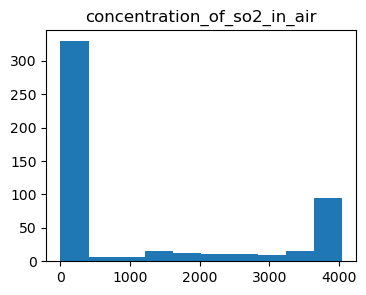

concentration_of_pm10_in_air


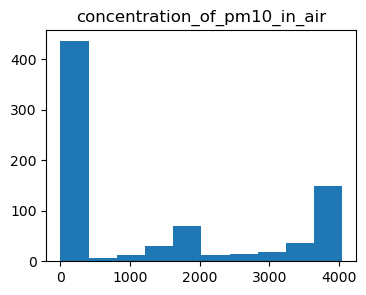

concentration_of_no2_in_air


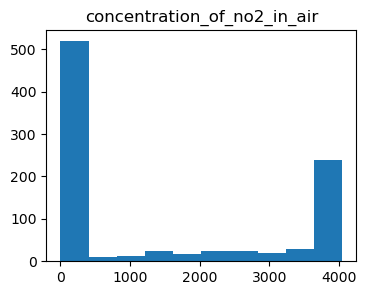

concentration_of_co_in_air


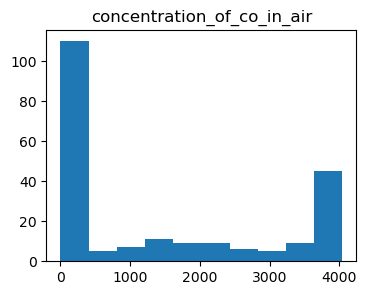

concentration_of_o3_in_air


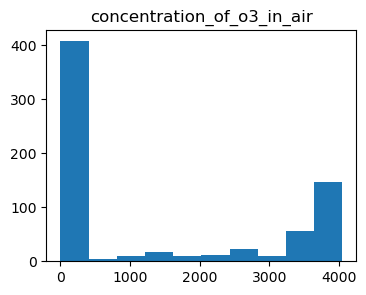

concentration_of_pm2_5_in_air


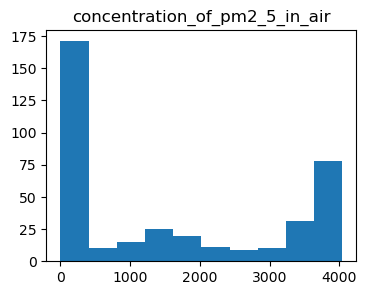

raw_value


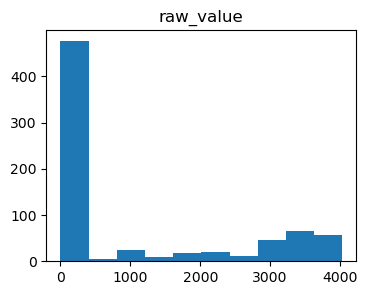

In [23]:
TOP=50
best_codes={}
for k in codes.keys():
    print(k)
    vals=[val for _, val in codes[k]]
    s=sorted(codes[k], key=lambda x:x[1])
    best_codes[k]=s[-TOP:]
    #print(indices)
    plt.figure(figsize=(4,3))
    plt.hist(vals)
    plt.title(k)
    plt.show()

In [24]:
best_codes

{'concentration_of_so2_in_air': [('STA-BELWZ02', 3971),
  ('STA-FI00352', 3973),
  ('STA-FR02028', 3973),
  ('STA-BG0018A', 3980),
  ('STA-BETR012', 3982),
  ('STA-BG0041A', 3986),
  ('STA-FI00356', 3991),
  ('STA-FR05072', 3993),
  ('STA-BETR240', 3997),
  ('STA-BETN132', 3999),
  ('STA-BG0026A', 3999),
  ('STA-BETR001', 4002),
  ('STA-BETN085', 4003),
  ('STA-BETN093', 4003),
  ('STA-BETN100', 4004),
  ('STA-BETR510', 4006),
  ('STA-BG0045A', 4007),
  ('STA-FI00339', 4007),
  ('STA-FI00208', 4008),
  ('STA-FR02004', 4008),
  ('STA-BETN060', 4009),
  ('STA-BETN066', 4009),
  ('STA-BG0057A', 4009),
  ('STA-FR02008', 4016),
  ('STA-CY0002R', 4018),
  ('STA-BG0040A', 4019),
  ('STA-EE0022A', 4020),
  ('STA-FR05069', 4021),
  ('STA-EE0019A', 4022),
  ('STA-EE0011R', 4024),
  ('STA-FR12015', 4026),
  ('STA-FR05083', 4027),
  ('STA-EE0015A', 4034),
  ('STA-FR05056', 4035),
  ('STA-CY0004A', 4036),
  ('STA-EE0020A', 4036),
  ('STA-FI00080', 4036),
  ('STA-EE0018A', 4037),
  ('STA-FI00184', 4

In [26]:
del best_codes['raw_value']

KeyError: 'raw_value'

Ideally, we need a couple of devices that have a lot of data in all phenomena. In other words, devices that are in all Top 50s... 

_Get the set of devices that are in all top 50 registered above_ 

(if there is an empty set, you can either choose another network, or increase the threshold (e.g. top 100).

In [27]:
my_set=[ind for ind,_ in best_codes[list(best_codes.keys())[0]]]
my_set=set(my_set)

for k in best_codes.keys():
    new_set=set([ind for ind,_ in best_codes[k]])
    my_set=new_set.intersection(my_set)

In [28]:
my_set

{'STA-BETN060', 'STA-BETN132'}

_For each of those decices, plot all measurements of 'concentration_of_co_in_air' from min_time to max_time_

In [29]:


def retrieve_href(key, href):
    if "?" in href:
        symbol="&"
    else:
        symbol="?"
    url=href+symbol+"token="+key+"&"
    res = requests.get(url)
    #print(url)
    jsonres=json.loads(res.content)
    return jsonres


def retrieve_all_data(key, hrefs):
    dataset={}

    for it in hrefs['items']:
        res=retrieve_href(key, it['href'])
        print(res['phenomenon']['code'])
        start=res['sensor_stats']['min_time']
        end=res['sensor_stats']['max_time']
        data=retrieve_href(key, res['measurements_url']+"/raw?start="+start+"&"+"end="+end)
        data=pd.DataFrame(data).set_index("begin")
        dataset[res['phenomenon']['code']]=data
        
    return dataset



In [30]:
chosen_sensors=my_set.copy()
chosen_sensor_refs={}
for el in my_set:
    chosen_sensor_refs[el]=retrieve(key, 'sensors', {'networks':my_network, 'devices':el})

https://api.opensensorweb.de/v0/networks/EEA-air/devices/STA-BETN132/sensors?token=tk1.06sue462ck4q9mqeg8na&
https://api.opensensorweb.de/v0/networks/EEA-air/devices/STA-BETN060/sensors?token=tk1.06sue462ck4q9mqeg8na&


In [31]:
location_one=retrieve_all_data(key, chosen_sensor_refs['STA-BETN132'])
print(my_places['STA-BETN132'])

concentration_of_so2_in_air
concentration_of_pm10_in_air
concentration_of_o3_in_air
concentration_of_no2_in_air
concentration_of_co_in_air
concentration_of_pm2_5_in_air
[5.630398, 49.719281]


In [32]:
location_two=retrieve_all_data(key, chosen_sensor_refs['STA-BETN060'])
print(my_places['STA-BETN060'])

concentration_of_so2_in_air
concentration_of_pm10_in_air
concentration_of_o3_in_air
concentration_of_no2_in_air
concentration_of_co_in_air
concentration_of_pm2_5_in_air
[3.457624, 50.616718]


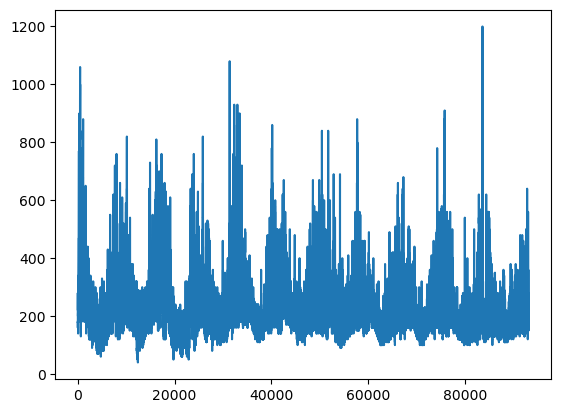

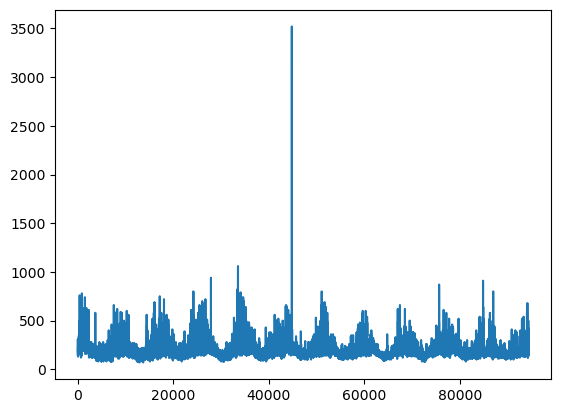

In [33]:
plt.plot(range(len(location_two['concentration_of_co_in_air'])), location_two['concentration_of_co_in_air'])
plt.show()
plt.plot(range(len(location_one['concentration_of_co_in_air'])), location_one['concentration_of_co_in_air'])

Cool, so NOW you can start playing with this kind of data... ideas for you to explore:

correlations between different measurements?

compare different places in Europe?

find (explain?) extreme cases?

correlate with other (external) variables of those locations (e.g. from openstreetmap)?

...